In [2]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn import set_config

set_config(transform_output = 'pandas')

import my_utils as mu

In [3]:
# read the data 
df = pd.read_csv('rfm.csv')

# drop the CustomerID col 
df = df.drop(columns = 'CustomerID')

# run head()
df.head()

,Recency,Frequency,MonetaryValue
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [4]:
# initiate scaler
scaler = StandardScaler()

# scale the data
df_scaled = scaler.fit_transform(df)

# run the scaled
df_scaled.head()

,Recency,Frequency,MonetaryValue
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


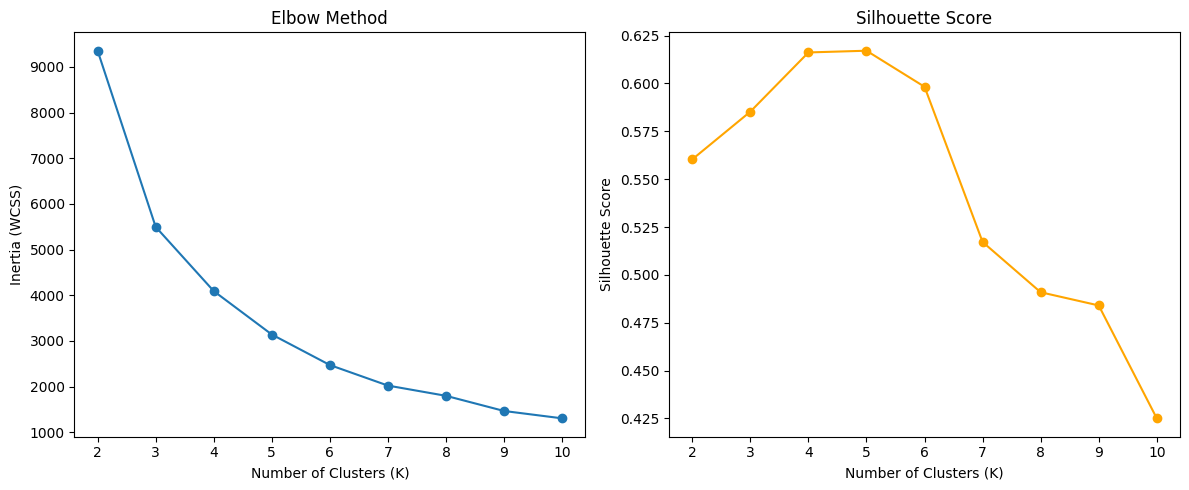

In [5]:
# find optimal cluster
mu.plot_optimal_k(df_scaled, range(2,11))

In [6]:
# initiate KMeans
kmeans = KMeans(n_clusters = 4, n_init = 'auto', random_state = 43)

# fit KMeans
kmeans.fit(df_scaled)

# cluster column 
df['cluster'] = kmeans.labels_

# run df
df.head()

,Recency,Frequency,MonetaryValue,cluster
0,326,1,77183.60,1
1,2,7,4310.00,2
2,75,4,1797.24,2
3,19,1,1757.55,2
4,310,1,334.40,0


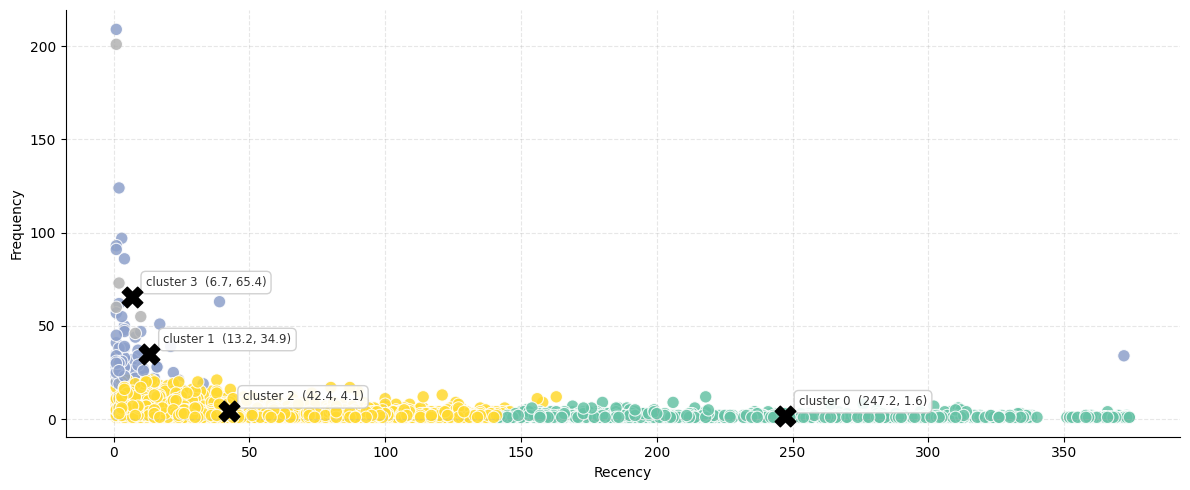

In [7]:
# visulaize the clusters on a plot
mu.plot_clusters(df, 'Recency', 'Frequency', kmeans, scaler)

In [ ]:
# show average and count values 
df.groupby('cluster')[['Recency', 'Frequency', 'MonetaryValue']].agg(['mean']).round(2).assign(Count=df.groupby('cluster').size().values)

,Recency,Frequency,MonetaryValue,Count
,mean,mean,mean,
cluster,,,,
0,247.22,1.55,557.06,1077
1,13.22,34.89,21820.15,95
2,42.38,4.14,1566.80,3159
3,6.71,65.43,184143.69,7


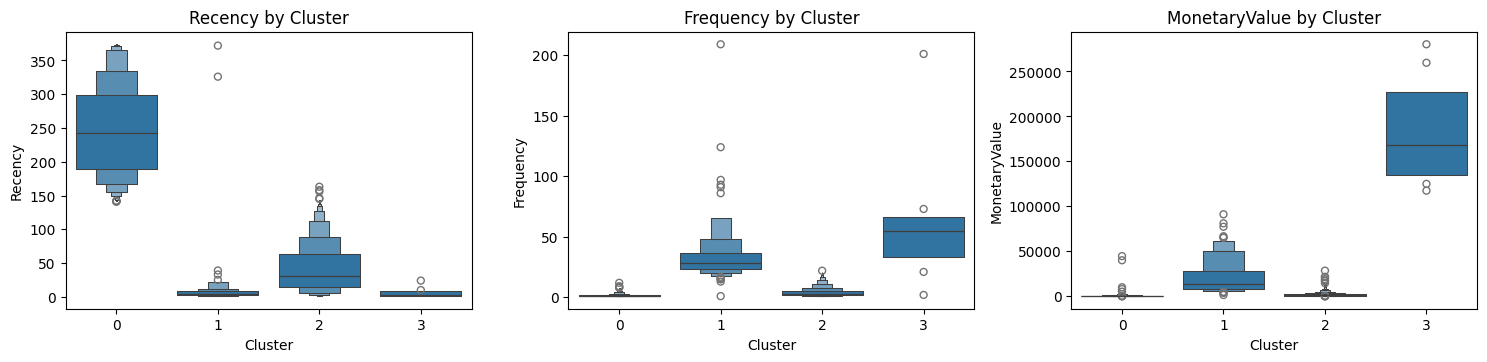

In [18]:
# Visualize the distribution of each feature per cluster
feature_cols = [col for col in df.columns if col != 'cluster']

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(feature_cols):

    sns.boxenplot(data=df, x='cluster', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


| | Cluster 0 |
|---|---|
| **🏷️ Name** | Lapsed / Churned Customers |
| **📅 Recency** | Worst — median ~240 days (~8 months absent) |
| **🔁 Frequency** | Very low — barely visited |
| **💰 Monetary** | Very low — minimal spending |
| **👥 Size** | Large group |
| **📊 Overall** | Failed on all 3 RFM dimensions |
| **🎯 Action** | Win-back campaign or suppress |

| | Cluster 1 |
|---|---|
| **🏷️ Name** | Frequent Buyers |
| **📅 Recency** | Low — shop recently and regularly |
| **🔁 Frequency** | High — visit the store often |
| **💰 Monetary** | Moderate to high — meaningful spending with some big spenders |
| **👥 Size** | Small group |
| **📊 Overall** | Strong across all 3 RFM dimensions |
| **🎯 Action** | Reward loyalty and nurture toward VIP status |

| | Cluster 2 |
|---|---|
| **🏷️ Name** | Occasional Buyers / Potential Loyalists |
| **📅 Recency** | Moderate — median ~50 days, IQR roughly 20–70 |
| **🔁 Frequency** | Moderate — less frequent than cluster 1 |
| **💰 Monetary** | Judicious — more than cluster 0, less than cluster 1 |
| **👥 Size** | Medium group |
| **📊 Overall** | Middle-tier across all 3 RFM dimensions |
| **🎯 Action** | Upsell campaigns to push toward frequent buyer status |

| | Cluster 3 |
|---|---|
| **🏷️ Name** | Champions / VIPs |
| **📅 Recency** | Excellent — median under 20 days, never truly absent |
| **🔁 Frequency** | Highest of all — median ~60–70 visits, some nearly 200 |
| **💰 Monetary** | Highest of all — spend freely, outliers exceeding $250K+ |
| **👥 Size** | Very small group |
| **📊 Overall** | Best across all 3 RFM dimensions — the crown jewel |
| **🎯 Action** | Protect at all costs — VIP perks, exclusive access, concierge treatment |

---

| | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| **🏷️ Name** | Lapsed / Churned | Frequent Buyers | Occasional Buyers | Champions / VIPs |
| **📅 Recency (mean)** | 247 days | 13 days | 42 days | 7 days |
| **🔁 Frequency (mean)** | 1.6 visits | 35 visits | 4.1 visits | 65 visits |
| **💰 Monetary (mean)** | $557 | $21,820 | $1,567 | $184,144 |
| **👥 Count** | 1,077 | 95 | 3,159 | 7 |
| **📊 % of Base** | **24.8%** | 2.2% | **72.8%** | 0.2% |
| **🎯 Action** | Win-back or suppress | Nurture toward VIP | Upsell & retain | Protect at all costs |

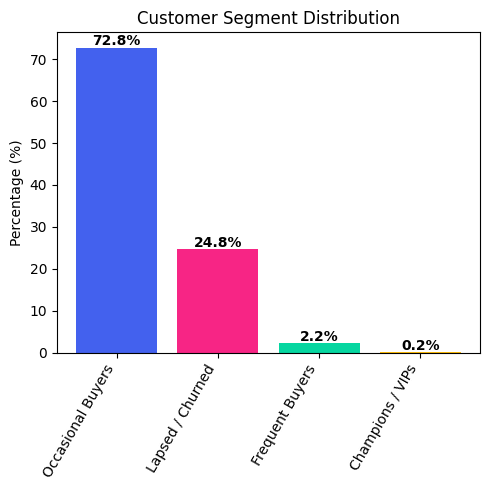

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

labels = ['Occasional Buyers', 'Lapsed / Churned', 'Frequent Buyers', 'Champions / VIPs']
sizes  = [72.8, 24.8, 2.2, 0.2]
colors = ['#4361EE', '#F72585', '#06D6A0', '#FFBE0B']

plt.figure(figsize=(5, 5))
bars = plt.bar(labels, sizes, color=colors)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{bar.get_height()}%',
             ha='center', fontweight='bold')

plt.title('Customer Segment Distribution')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()